Research Question:
"How can Principal Component Analysis (PCA) be applied to uncover key patterns in hospital patient data?"

In [1]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
#Loading the dataset
medical_clean = pd.read_csv('medical_clean_D212.csv')

In [3]:
#Information about the dataset
medical_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CaseOrder           10000 non-null  int64  
 1   Customer_id         10000 non-null  object 
 2   Interaction         10000 non-null  object 
 3   UID                 10000 non-null  object 
 4   City                10000 non-null  object 
 5   State               10000 non-null  object 
 6   County              10000 non-null  object 
 7   Zip                 10000 non-null  int64  
 8   Lat                 10000 non-null  float64
 9   Lng                 10000 non-null  float64
 10  Population          10000 non-null  int64  
 11  Area                10000 non-null  object 
 12  TimeZone            10000 non-null  object 
 13  Job                 10000 non-null  object 
 14  Children            10000 non-null  int64  
 15  Age                 10000 non-null  int64  
 16  Incom

In [4]:
#Selecting continuous variables
variables = ['Age', 'Income', 'VitD_levels', 'Initial_days', 'TotalCharge', 'Additional_charges']
df = medical_clean[variables].copy()

In [5]:
#Checking for duplicate values
print(df.duplicated())

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool


In [6]:
#Checking for missing values
print(df.isnull().sum())

Age                   0
Income                0
VitD_levels           0
Initial_days          0
TotalCharge           0
Additional_charges    0
dtype: int64


In [7]:
#Identifying outliers based on Z-scores
z_scores = np.abs(zscore(df[variables]))
z_score_outliers = (z_scores > 3).sum(axis=0)
print("Outliers based on Z-score method:")
print(z_score_outliers)

Outliers based on Z-score method:
Age                     0
Income                143
VitD_levels            24
Initial_days            0
TotalCharge             0
Additional_charges      0
dtype: int64


<Axes: xlabel='Income'>

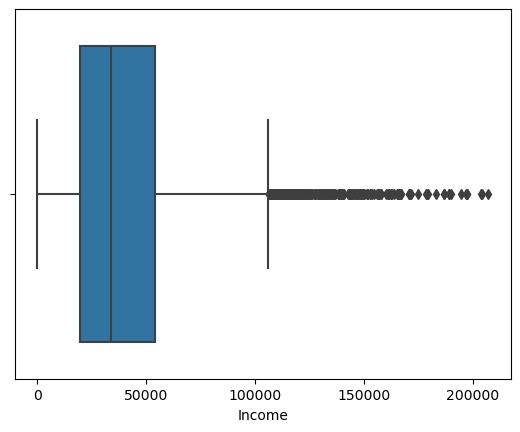

In [8]:
#Checking for outliers for Income
sns.boxplot(x = 'Income', data = df)

<Axes: xlabel='VitD_levels'>

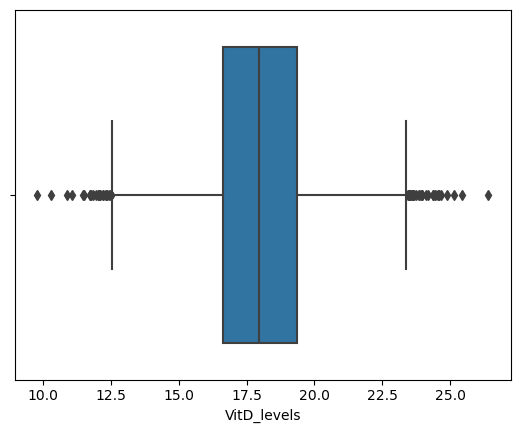

In [9]:
#Checking for outliers for VitD_levels
sns.boxplot(x = 'VitD_levels', data = df)

In [10]:
#Separate features from label
X = df
y = medical_clean['ReAdmis']

In [11]:
#Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
#PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [13]:
#Explained and cumulative variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

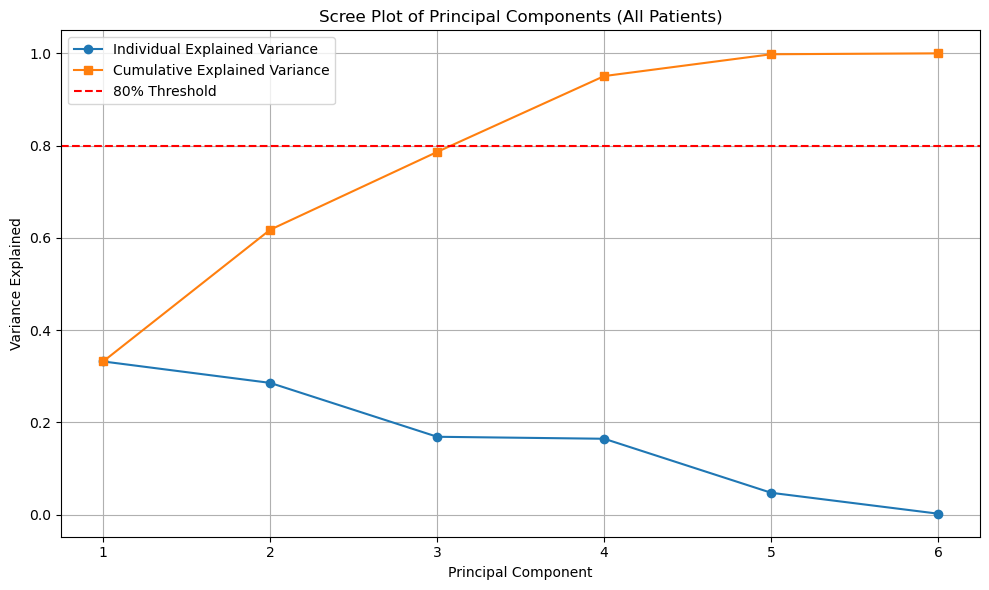

In [14]:
#Scree plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', label='Individual Explained Variance')
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='s', label='Cumulative Explained Variance')
plt.axhline(y=0.8, color='r', linestyle='--', label='80% Threshold')

plt.title("Scree Plot of Principal Components (All Patients)")
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

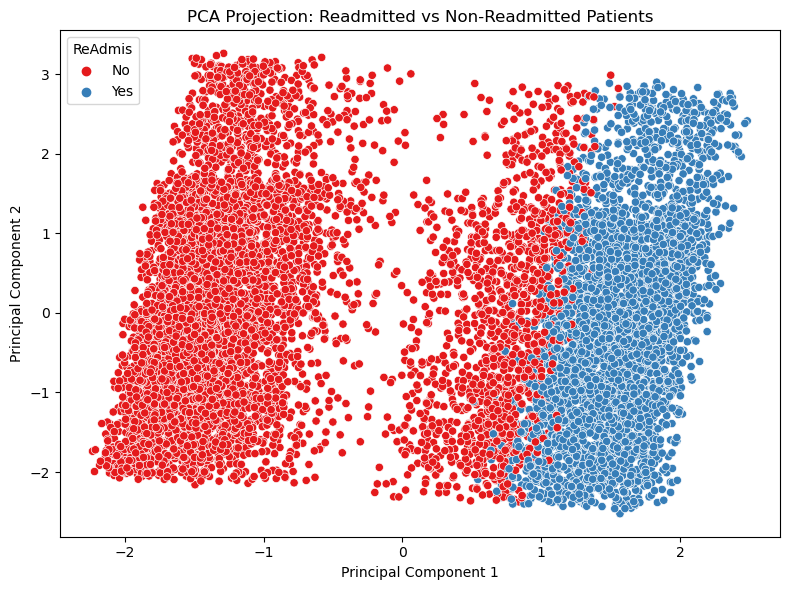

In [23]:
#Scatterplot colored by readmisiion
pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X.shape[1])])
pca_df['ReAdmis'] = y.values

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='ReAdmis', palette='Set1')
plt.title('PCA Projection: Readmitted vs Non-Readmitted Patients')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title="ReAdmis")
plt.tight_layout()
plt.show()

In [16]:
#Variance exp
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

In [22]:
#Varience summary
print("Explained Variance (First 4 PCs):")
for i in range(4):
    print(f"PC{i+1}: {explained_variance[i]:.4f} (Cumulative: {cumulative_variance[i]:.4f})")


Explained Variance (First 4 PCs):
PC1: 0.3320 (Cumulative: 0.3320)
PC2: 0.2856 (Cumulative: 0.6176)
PC3: 0.1687 (Cumulative: 0.7863)
PC4: 0.1644 (Cumulative: 0.9508)


In [21]:
#Get loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(variables))],
    index=variables
)

print("\nTop Variables Contributing to PC1–PC4:")
print(loadings.iloc[:, :4].sort_values(by='PC1', ascending=False))


Top Variables Contributing to PC1–PC4:
                         PC1       PC2       PC3       PC4
TotalCharge         0.702270 -0.080918  0.005929  0.011405
Initial_days        0.701146 -0.091464  0.008280  0.011129
Additional_charges  0.086047  0.701555  0.022194  0.001522
Age                 0.085851  0.701556  0.017940  0.001094
VitD_levels        -0.001680  0.019269 -0.712533  0.701368
Income             -0.020851 -0.018816  0.700984  0.712619


In [18]:
#Total variance captured by the first 6 components
total_variance_4 = cumulative_variance[3] * 100
print(f"Total variance explained by first 4 components: {total_variance_4:.2f}%")

Total variance explained by first 4 components: 95.08%


In [19]:
# Number of components that explain at least 80% variance
n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1
print(f"Number of components explaining >= 80% variance: {n_components_80}")

Number of components explaining >= 80% variance: 4


In [26]:
#Convert scaled numpy array to a dataframe
scaled_df = pd.DataFrame(X_scaled, columns=variables)

In [28]:
#Variance summary dataframe
variance_df = pd.DataFrame({
    'Explained Variance': explained_variance,
    'Cumulative Variance': cumulative_variance
})

In [29]:
#Export data
scaled_data_path = 'output/scaled_medical_data_PCA_D212_II.csv'
scaled_df.to_csv(scaled_data_path, index=False)
new_data_path = 'output/new_medical_data_PCA_D212_II.csv'
df.to_csv(new_data_path, index=False)
variance_path =new_data_path = 'output/variance_summary_PCA_D212_II.csv'
variance_df.to_csv(variance_path, index=False)
loadings_path = 'output/loadings_PCA_D212_II.csv'
loadings.to_csv(loadings_path)